# Плотное векторное представление слов для определения тональности текста отзывов на фильмы из IMDb (Internet Movie Database) — PyTorch

Этот ноутбук повторяет пример «Плотное векторное представление слов» из урока 5 и выполнен
полностью на **PyTorch**. Данные — исходный набор IMDb (отзывы и частотный словарь слов);
мы загружаем их напрямую файлами, поэтому для запуска ноутбука достаточно PyTorch, NumPy и Matplotlib.

Учебный курс "[Программирование глубоких нейронных сетей на Python](https://openedu.ru/course/urfu/PYDNN/)".

## Набор данных IMDb movie review

[Набор данных IMDb movie review](https://ai.stanford.edu/~amaas/data/sentiment/) создан для задач определения тональности текста. Набор включает отзывы на фильмы с сайта [IMDb](https://www.imdb.com). Отзывы только явно положительные (оценка >= 7) или отрицательные (оценка <= 4), нейтральные отзывы в набор данных не включались.

Размер набора данных 50 тыс. отзывов:
- Набор данных для обучения - 25 тыс. отзывов
- Набор данных для тестирования - 25 тыс. отзывов

Количество положительных и отрицательных отзывов одинаковое.

Разметка набора данных:
- 0 - отзыв отрицательный
- 1 - отзыв положительный

С точки зрения машинного обучения это задача бинарной классификации.

Набор данных описан в статье: [Andrew L. Maas, Raymond E. Daly, Peter T. Pham, Dan Huang, Andrew Y. Ng, and Christopher Potts. (2011). Learning Word Vectors for Sentiment Analysis. The 49th Annual Meeting of the Association for Computational Linguistics (ACL 2011)](https://ai.stanford.edu/~amaas/papers/wvSent_acl2011.pdf).

Отзывы уже разбиты на последовательности номеров слов. Номер слова — это его **ранг в частотном словаре**: чем чаще слово встречается в отзывах, тем меньше его номер (1 — самое частое слово). Никаких смещений не применяется: код слова из словаря в точности совпадает с номером токена в последовательности и со строкой таблицы векторов.

Отдельно зарезервирован один специальный токен:
- 0 — заполнитель (padding): его дописывают при выравнивании длин отзывов, в самих отзывах его нет.

<img src="https://www.dropbox.com/s/grd17bkapocb92o/imdb_movie_reviews.png?dl=1" width="600">

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import urllib.request
import json
import os
from io import BytesIO
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA доступна:", torch.cuda.is_available())
print("Устройство:", device)

PyTorch: 2.1.2+cu121
CUDA доступна: True
Устройство: cuda:0


## Загружаем данные

Файлы `imdb.npz` (отзывы как последовательности номеров слов) и `imdb_word_index.json`
(частотный словарь: слово -> ранг) — это архив и словарь исходного набора данных IMDb.
Мы скачиваем их напрямую и сохраняем локально: для запуска ноутбука достаточно
PyTorch, NumPy и Matplotlib.

In [28]:
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

# Файлы скачиваются из открытого архива исходного набора данных
GCS = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/"

In [29]:
def download_if_absent(name, url):
    path = data_dir / name
    if not path.exists():
        print(f"Скачиваем {name} ...")
        urllib.request.urlretrieve(url, path)
    return path

npz_path = download_if_absent("imdb.npz", GCS + "imdb.npz")
word_index_path = download_if_absent("imdb_word_index.json", GCS + "imdb_word_index.json")

In [30]:
def load_imdb(num_words=None):
    # Наборы обучения и тестирования уже в файле: 25 тыс. отзывов в каждом
    data = np.load(npz_path, allow_pickle=True)
    (x_train, y_train), (x_test, y_test) = (data["x_train"], data["y_train"]), (data["x_test"], data["y_test"])
    if num_words is not None:
        # Оставляем только num_words самых частотных слов: токены w >= num_words отбрасываем
        x_train = [[int(w) for w in seq if w < num_words] for seq in x_train]
        x_test = [[int(w) for w in seq if w < num_words] for seq in x_test]
    return np.array(x_train, dtype=object), y_train, np.array(x_test, dtype=object), y_test

max_words = 10000
x_train, y_train, x_test, y_test = load_imdb(num_words=max_words)

print(f"Обучение: {len(x_train)} отзывов | Тест: {len(x_test)} отзывов")
print(f"Доля положительных в обучающем наборе: {y_train.mean():.3f}")

Обучение: 25000 отзывов | Тест: 25000 отзывов
Доля положительных в обучающем наборе: 0.500


### Как тексты превращаются в числа

Модель работает только с числами, поэтому каждое слово заменяется своим номером в частотном словаре:

1. По всем отзывам строится словарь уникальных слов, отсортированных по частоте встречаемости: чем чаще слово, тем меньше его номер.
2. Рецензия превращается в последовательность номеров слов — каждый номер $w$ соответствует слову в словаре.
3. Ограничение словаря: `max_words = 10000` оставляет только самые частотные слова, из каждой последовательности отбрасываются токены $w \ge 10000$.

Нумерация слов в нашем наборе:

- 0 зарезервирован под заполнитель (padding) — в самих отзывах такого токена нет, его дописывают при выравнивании длин;
- 1 и выше — реальные слова: номер слова равен его рангу в частотном словаре (1 — самое частое слово, 2 — второе по частоте и т. д.).

В следующем разделе посмотрим на отзывы глазами этих чисел.

## Просмотр данных

Рецензия (последовательность номеров слов)

Правильный ответ (1 - положительный отзыв)

## Подготовка данных для обучения

### Зачем дополнять рецензии до одинаковой длины

Связка слоёв `nn.Embedding` → `nn.Flatten` → `nn.Linear` требует вход фиксированной формы: все рецензии обязаны иметь одинаковую длину. В наборе отзывы разной длины $L_i$, поэтому:

- если $L_i > \text{maxlen} = 200$ — оставляем последние 200 слов (считаем, что конец отзыва важнее):
  $$ \tilde{x}_i = [x_{i,\,L_i-200}, \, \dots ,\, x_{i,\,L_i}] $$
- если $L_i < 200$ — дописываем в конец нулевые заполнители (токен 0, padding):
  $$ \tilde{x}_i = [\,x_{i,1},\, \dots ,\, x_{i,L_i},\, \underbrace{0,\, \dots ,\, 0}_{200 - L_i}\,] $$

После дополнения каждая рецензия имеет форму `(200,)`, а весь набор — `(N, 200)`. Нулевые позиции почти не влияют на результат: вектор нулевой строки таблицы встраивания сеть по сути игнорирует.

In [36]:
maxlen = 200

# Собственное выравнивание длин:
#   - длинные рецензии укорачиваем до последних maxlen слов (хвост);
#   - короткие рецензии дополняем нулями справа.
def pad_sequences_post(seqs, maxlen):
    out = []
    for seq in seqs:
        seq = list(seq)
        if len(seq) > maxlen:
            seq = seq[-maxlen:]
        if len(seq) < maxlen:
            seq = seq + [0] * (maxlen - len(seq))
        out.append(seq)
    return np.array(out, dtype=np.int64)

x_train = pad_sequences_post(x_train, maxlen)
x_test = pad_sequences_post(x_test, maxlen)

# Превращаем в тензоры PyTorch
x_train = torch.from_numpy(x_train)
y_train = torch.from_numpy(y_train.astype(np.float32))
x_test = torch.from_numpy(x_test)
y_test = torch.from_numpy(y_test.astype(np.float32))

In [8]:
y_train[1]

tensor(1.)

## Создаем нейронную сеть

Модель на PyTorch для предсказания тональности по векторам слов:

- `Embedding(10000, 2)` — обучаемая таблица из 10 тыс. слов, каждое слово - вектор из 2 чисел;
- `Dropout(0.2)` — регуляризация;
- `Flatten()` — вытягиваем всю рецензию в один вектор;
- `Linear(400, 10)` + `Linear(10, 1)` — скрытый слой и один выходной нейрон (логит тональности).

Выход - **логит** (число до сигмоиды), поэтому считаем потери через `BCEWithLogitsLoss`.

### Математика модели

Разберём, что делает каждый модуль сети и какие формулы за ним стоят.

**1. Слой встраивания (Embedding).** `nn.Embedding(max_words, 2)` хранит таблицу весов $E \in \mathbb{R}^{V \times d}$, где $V = 10000$ — размер словаря, $d = 2$ — размерность вектора слова. Слово с номером $w$ (его рангом в частотном словаре) заменяется строкой таблицы:

$$ v_w = E[w], \qquad E \in \mathbb{R}^{10000 \times 2} $$

Математически это то же самое, что умножить one-hot вектор $o_w$ (единица в позиции $w$, нули в остальных) на матрицу $E$:

$$ v_w = o_w^{\top} E $$

Обе координаты $v_w^{(0)}$ и $v_w^{(1)}$ **обучаются** вместе со всей сетью: по градиенту функции потерь обновляются только те строки таблицы, слова которых реально встретились в рецензиях пакета.

**2. Dropout.** `nn.Dropout(0.2)` во время обучения с вероятностью $p = 0.2$ «выключает» случайную долю элементов и масштабирует оставшиеся, чтобы масштаб сигнала сохранился:

$$ \tilde{v}_i = \frac{m_i \cdot v_i}{1 - p}, \qquad m_i \sim \mathrm{Bernoulli}(1 - p) $$

Это регуляризация: сеть не может опереться на отдельную координату, ведь её может «занулить» dropout. При проверке и тестировании слой работает как тождество.

**3. Flatten.** После встраивания пакет имеет форму `(batch, 200, 2)` (200 слов, у каждого вектор из 2 чисел). `nn.Flatten()` вытягивает его в один плоский вектор из $200 \cdot 2 = 400$ элементов:

$$ x \in \mathbb{R}^{200 \times 2} \;\longrightarrow\; \mathrm{vec}(x) \in \mathbb{R}^{400} $$

**4. Полносвязная часть (два слоя Linear).** `nn.Linear(400, 10)` даёт скрытое представление, `nn.Linear(10, 1)` — одно число, **логит**:

$$ h = W_1^{\top} x + b_1, \qquad z = W_2^{\top} h + b_2, \qquad W_1 \in \mathbb{R}^{400 \times 10},\; W_2 \in \mathbb{R}^{10} $$

**5. Сигмоида на выходе.** В сети сигмоиды нет (об этом ниже), но предсказание — вероятность положительного отзыва — получается из логита именно через неё:

$$ \hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}} \in (0, 1) $$

Правило классификации: отзыв положительный ($y = 1$), если $\hat{y} \ge 0.5$, что эквивалентно $z \ge 0$.

In [41]:
model = nn.Sequential(
    nn.Embedding(max_words, 2),              # таблица "слово -> вектор из 2 чисел"
    nn.Dropout(0.2),
    nn.Flatten(),
    nn.Linear(maxlen * 2, 10),  
    nn.Linear(10, 1)                 # один выходной нейрон (без сигмоиды!)
).to(device)

print(model)
print(f"Количество параметров: {sum(p.numel() for p in model.parameters()):,}")

Sequential(
  (0): Embedding(10000, 2)
  (1): Dropout(p=0.2, inplace=False)
  (2): Flatten(start_dim=1, end_dim=-1)
  (3): Linear(in_features=400, out_features=10, bias=True)
  (4): Linear(in_features=10, out_features=1, bias=True)
)
Количество параметров: 24,021


In [44]:
# from torchsummary import summary
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Embedding: 1-1                         20,000
├─Dropout: 1-2                           --
├─Flatten: 1-3                           --
├─Linear: 1-4                            4,010
├─Linear: 1-5                            11
Total params: 24,021
Trainable params: 24,021
Non-trainable params: 0

In [59]:
w1 = list(model[0].parameters())[0].detach().cpu().numpy()

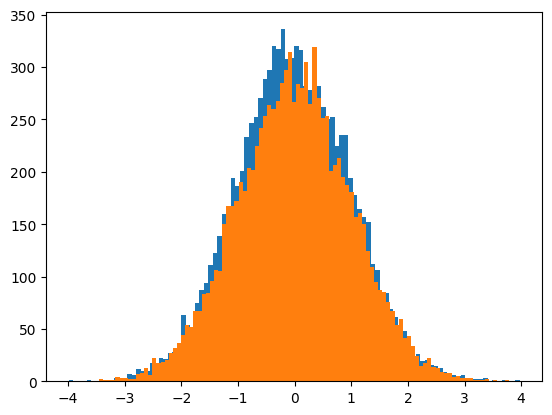

In [60]:
plt.hist(w1[:,0],100);
plt.hist(w1[:,1],100);

In [61]:
optimizer = torch.optim.Adam(model.parameters())
loss_fn = nn.BCEWithLogitsLoss()

### Функция потерь — бинарная перекрёстная энтропия

Пусть $y \in \{0, 1\}$ — истинная метка отзыва, $\hat{y}$ — предсказанная вероятность положительного класса. Логистическая (бинарная перекрёстная) энтропия по одному примеру:

$$ L(y, \hat{y}) = -\Big[\, y \ln \hat{y} + (1 - y) \ln (1 - \hat{y}) \,\Big] $$

По пакету из $N$ примеров берём среднее и минимизируем его градиентным спуском:

$$ \mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \Big[\, y_i \ln \hat{y}_i + (1 - y_i) \ln (1 - \hat{y}_i) \,\Big] $$

Свойство: чем увереннее модель ошибается (например, $y_i = 1$, а $\hat{y}_i \to 0$), тем $\ln \hat{y}_i \to -\infty$ и штраф сильнее — именно это заставляет сеть учиться.

**Почему потери считают по логитам.** `nn.BCEWithLogitsLoss()` принимает на вход логиты $z$, а не вероятности. Это объединение сигмоиды и логарифма в одну численно устойчивую формулу:

$$ L = \begin{cases} \ln\big(1 + e^{-z}\big), & y = 1 \\[4pt] \ln\big(1 + e^{z}\big), & y = 0 \end{cases} $$

При $z \to -\infty$ напрямую считать $\ln(1 / (1 + e^{-z}))$ нельзя (потеря младших разрядов, переполнение), а формула выше не даёт промежуточных значений $\sigma(z)$ и считается стабильно. Поэтому сигмоиду в сеть отдельно не встраивают: для предсказаний её применяют на этапе оценки.

## Обучаем нейронную сеть

### Оптимизатор Adam — как обновляются веса

Потери минимизирует оптимизатор **Adam** (Adaptive Moment Estimation). Adam поддерживает скользящие средние градиента $m_t$ и его квадрата $v_t$:

$$ m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t, \qquad v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 $$

где $g_t = \nabla_\theta \mathcal{L}$ — градиент функции потерь по параметрам $\theta$. Так как средние стартуют с нуля, на первых шагах их смещение исправляется (bias correction):

$$ \hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \qquad \hat{v}_t = \frac{v_t}{1 - \beta_2^t} $$

Шаг обновления параметров:

$$ \theta_t = \theta_{t-1} - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \varepsilon} $$

Смысл: направление задаёт сглаженный градиент $\hat{m}_t$ (момент, как при качении шара), а размер шага автоматически масштабируется — на «крутых» направлениях с большим $\hat{v}_t$ шаг меньше, на «пологих» больше. Стандартные параметры: $\alpha = 0.001$, $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\varepsilon = 10^{-8}$.

Обучение идёт по **мини-пакетам**: за шаг градиент считается по 128 рецензиям, а не по всей выборке (это быстрее и устойчивее). Отдельно на 10% обучающих примеров (переменная `val_idx`) измеряется точность во время обучения — так видно, не переобучается ли сеть. Схема: обучение (`model.train`, включён dropout) → проверка (`model.eval`, dropout выключен, градиенты не считаются).

In [62]:
epochs = 50
batch_size = 128

# Отделяем 10% обучающих данных для проверки во время обучения
train_idx, val_idx = train_test_split(np.arange(x_train.size(0)), test_size=0.1, random_state=42)
train_loader = DataLoader(TensorDataset(x_train[train_idx], y_train[train_idx]),
                          batch_size=batch_size, shuffle=True, num_workers=2)

history = {"loss": [], "accuracy": [], "val_accuracy": []}
for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb).squeeze(1)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        preds = (torch.sigmoid(logits) >= 0.5).float()
        correct += (preds == yb).sum().item()
        total += xb.size(0)

    # Точность на проверочном наборе
    model.eval()
    with torch.no_grad():
        val_correct = 0
        for xb, yb in DataLoader(TensorDataset(x_train[val_idx], y_train[val_idx]),
                                 batch_size=512, shuffle=False):
            xb, yb = xb.to(device), yb.to(device)
            preds = (torch.sigmoid(model(xb).squeeze(1)) >= 0.5).float()
            val_correct += (preds == yb).sum().item()
        val_acc = val_correct / len(val_idx)

    acc = correct / total
    history["loss"].append(total_loss / total)
    history["accuracy"].append(acc)
    history["val_accuracy"].append(val_acc)
    print(f"Эпоха {epoch:2d} | loss {history['loss'][-1]:.4f} | "
          f"accuracy {acc:.3f} | val_accuracy {val_acc:.3f}")

Эпоха  1 | loss 0.6993 | accuracy 0.522 | val_accuracy 0.521
Эпоха  2 | loss 0.6838 | accuracy 0.557 | val_accuracy 0.549
Эпоха  3 | loss 0.6725 | accuracy 0.583 | val_accuracy 0.587
Эпоха  4 | loss 0.6501 | accuracy 0.619 | val_accuracy 0.626
Эпоха  5 | loss 0.6181 | accuracy 0.660 | val_accuracy 0.673
Эпоха  6 | loss 0.5834 | accuracy 0.693 | val_accuracy 0.706
Эпоха  7 | loss 0.5517 | accuracy 0.721 | val_accuracy 0.728
Эпоха  8 | loss 0.5206 | accuracy 0.745 | val_accuracy 0.750
Эпоха  9 | loss 0.4935 | accuracy 0.761 | val_accuracy 0.767
Эпоха 10 | loss 0.4710 | accuracy 0.781 | val_accuracy 0.778
Эпоха 11 | loss 0.4509 | accuracy 0.790 | val_accuracy 0.791
Эпоха 12 | loss 0.4269 | accuracy 0.805 | val_accuracy 0.803
Эпоха 13 | loss 0.4087 | accuracy 0.815 | val_accuracy 0.808
Эпоха 14 | loss 0.3944 | accuracy 0.825 | val_accuracy 0.817
Эпоха 15 | loss 0.3811 | accuracy 0.832 | val_accuracy 0.825
Эпоха 16 | loss 0.3672 | accuracy 0.841 | val_accuracy 0.830
Эпоха 17 | loss 0.3573 |

Эпоха  2 | loss 0.6815 | accuracy 0.561 | val_accuracy 0.570


Эпоха  3 | loss 0.6677 | accuracy 0.588 | val_accuracy 0.607


Эпоха  4 | loss 0.6440 | accuracy 0.628 | val_accuracy 0.642


Эпоха  5 | loss 0.6156 | accuracy 0.661 | val_accuracy 0.680


...

Эпоха 46 | loss 0.2065 | accuracy 0.918 | val_accuracy 0.868


Эпоха 47 | loss 0.2016 | accuracy 0.921 | val_accuracy 0.868


Эпоха 48 | loss 0.1984 | accuracy 0.922 | val_accuracy 0.870


Эпоха 49 | loss 0.1962 | accuracy 0.922 | val_accuracy 0.870


Эпоха 50 | loss 0.1946 | accuracy 0.923 | val_accuracy 0.868


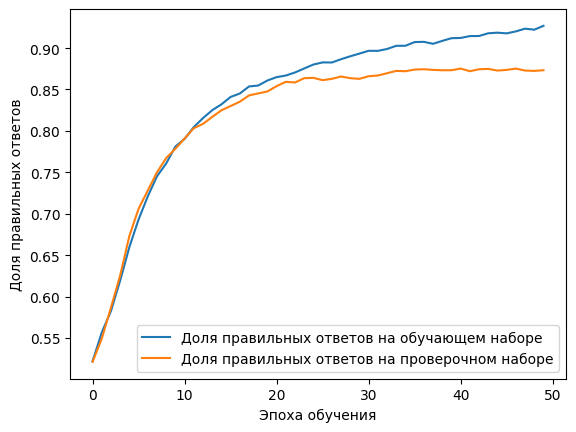

In [63]:
plt.plot(history['accuracy'],
         label='Доля правильных ответов на обучающем наборе')
plt.plot(history['val_accuracy'],
         label='Доля правильных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля правильных ответов')
plt.legend()
plt.show()

## Проверяем работу сети на тестовом наборе данных

Качество на отложенном тестовом наборе (25 тыс. отзывов, не участвовавших в обучении) измеряется метрикой **accuracy** — долей верно предсказанных меток:

$$ \mathrm{Acc} = \frac{1}{N_{\mathrm{test}}} \sum_{i=1}^{N_{\mathrm{test}}} \mathbb{I}\big[\hat{y}_i = y_i\big] $$

где $\mathbb{I}[\cdot]$ — индикатор совпадения предсказанного класса с истинной меткой. Проверку делаем в блоке `torch.no_grad()` (градиенты не нужны — это экономит память) и пакетами по 512 примеров.

In [64]:
model.eval()
test_correct = 0
test_loss = 0.0
with torch.no_grad():
    for xb, yb in DataLoader(TensorDataset(x_test, y_test), batch_size=512):
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb).squeeze(1)
        test_loss += loss_fn(logits, yb).item() * xb.size(0)
        preds = (torch.sigmoid(logits) >= 0.5).float()
        test_correct += (preds == yb).sum().item()

scores = (test_loss / x_test.size(0), test_correct / x_test.size(0))
print(f"Потери на тестовом наборе: {scores[0]:.4f}")
print(f"Точность на тестовом наборе: {scores[1]:.4f}")
scores

Потери на тестовом наборе: 0.3501
Точность на тестовом наборе: 0.8663


(0.3500904165458679, 0.86628)

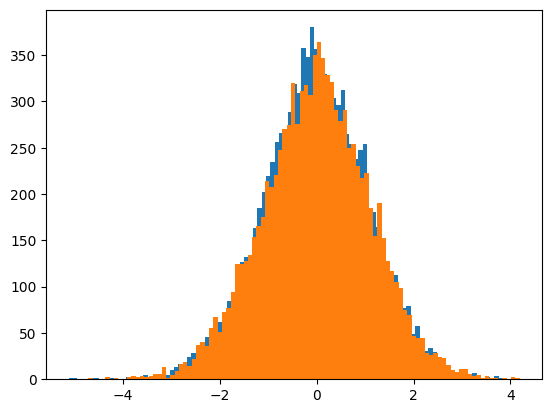

In [67]:
w2 = list(model[0].parameters())[0].detach().cpu().numpy()
plt.hist(w2[:,0],100);
plt.hist(w2[:,1],100);

## Исследуем обученное плотное векторное представление слов

**Получаем матрицу плотных векторных представлений слов.** Первый слой модели - `nn.Embedding`; его веса и есть таблица слово -> вектор. В нашем случае вектор каждого слова состоит всего из 2 чисел, поэтому его можно нарисовать на плоскости.

### Что такое обученное векторное представление слова

После обучения `embedding_matrix` — это таблица, в которой **каждая строка — вектор своего слова** из 2 чисел. Такие векторы называют *встраиванием* (embedding), или плотным векторным представлением слова.

Смысл подхода (дистрибуционная гипотеза): значение слова определяется текстами, где оно встречается, поэтому сеть учит координаты не «в лоб», а так, чтобы они были полезны для ответа. Наша сеть по сумме векторов всех слов рецензии должна выдать её тональность, значит «положительные» слова вынуждены оказаться в одной области плоскости, а «отрицательные» — в другой, иначе не разделить классы.

Благодаря размерности $d = 2$ каждое слово можно нарисовать точкой и глазами увидеть, как распределились слова по смыслу.

In [69]:
embedding_matrix = model[0].weight.detach().cpu().numpy()
embedding_matrix.shape

(10000, 2)

In [70]:
embedding_matrix[:5]

array([[-0.04926668,  0.07545155],
       [ 0.20704265, -0.25196478],
       [-0.06620488,  0.81415784],
       [ 0.24350739, -0.20830339],
       [-0.25616226,  0.48290482]], dtype=float32)

**Загружаем словарь с номерами слов** (JSON-файл частотного словаря набора)

In [71]:
with open(word_index_path) as f:
    word_index_org = json.load(f)
    
# Первые записи словаря
list(word_index_org.items())[:5]

[('fawn', 34701),
 ('tsukino', 52006),
 ('nunnery', 52007),
 ('sonja', 16816),
 ('vani', 63951)]

Строим словарь `слово -> номер`. Номер слова в нашем наборе — это его ранг в частотном
словаре (значение из JSON), т. е. ровно тот номер токена, под которым слово сидит в
последовательности и в таблице векторов: никакого сдвига не требуется. Единственный
служебный токен — заполнитель `0` (padding), которого в самом словаре нет.

In [72]:
word_index = dict()
for word, number in word_index_org.items():
    word_index[word] = number
word_index["<Заполнитель>"] = 0

**Ищем векторы для слов**

In [73]:
word = 'good'
word_number = word_index[word]
print('Номер слова', word_number)
print('Вектор для слова', embedding_matrix[word_number])

Номер слова 49
Вектор для слова [0.3664388 1.2373339]


## Сохраняем обученные плотные векторные представления в файл

**Составляем реверсивный словарь токенов (слов)**

In [74]:
reverse_word_index = dict()
for key, value in word_index.items():
    reverse_word_index[value] = key

**Записываем плотные векторные представления в файл**

In [75]:
filename = 'data/imdb_embeddings_pytorch.csv'
print('Сохраняем векторы слов в файл', filename)

Сохраняем векторы слов в файл data/imdb_embeddings_pytorch.csv


In [76]:
with open(filename, 'w') as f:
    for word_num in range(max_words):
        word = reverse_word_index[word_num]
        vec = embedding_matrix[word_num]
        try:
            f.write(word + ",")
            f.write(','.join([str(x) for x in vec]) + "\n")
        except UnicodeEncodeError:
            pass
print('Готово, записано строк:', max_words)

Готово, записано строк: 10000


## Визуализация плотных векторных представлений слов

Так как вектор каждого слова состоит из 2 чисел, нарисуем все 10 тысяч слов точками на плоскости.

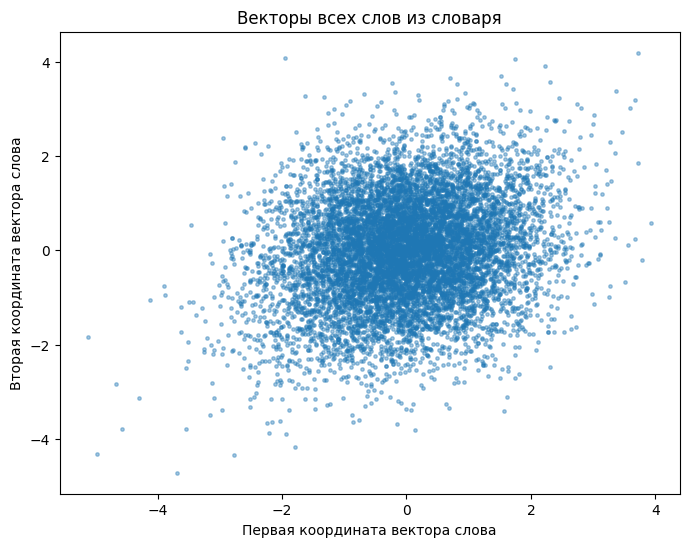

In [77]:
plt.figure(figsize=(8, 6))
plt.scatter(embedding_matrix[:, 0], embedding_matrix[:, 1], s=6, alpha=0.4)
plt.xlabel('Первая координата вектора слова')
plt.ylabel('Вторая координата вектора слова')
plt.title('Векторы всех слов из словаря')
plt.show()

Выбираем коды слов, по которым можно определить тональность отзыва

In [79]:
review = ['brilliant', 'fantastic', 'amazing', 'good',
          'bad', 'awful', 'crap', 'terrible', 'trash']
enc_review = []
for word in review:
    enc_review.append(word_index[word])
enc_review

[527, 774, 477, 49, 75, 370, 592, 391, 1154]

Получаем векторное представление интересующих нас слов

In [80]:
review_vectors = embedding_matrix[enc_review]
review_vectors

array([[ 3.356622  ,  0.26025453],
       [ 2.369297  ,  2.1225104 ],
       [ 3.0527716 ,  1.8285804 ],
       [ 0.3664388 ,  1.2373339 ],
       [-2.047534  , -1.7761796 ],
       [-4.6650777 , -2.8399835 ],
       [-1.4918541 , -1.9126749 ],
       [-2.6891747 , -2.1849816 ],
       [-0.5142209 , -1.7780827 ]], dtype=float32)

Визуализация обученного плотного векторного представления слов, по которым можно определить эмоциональную окраску текста

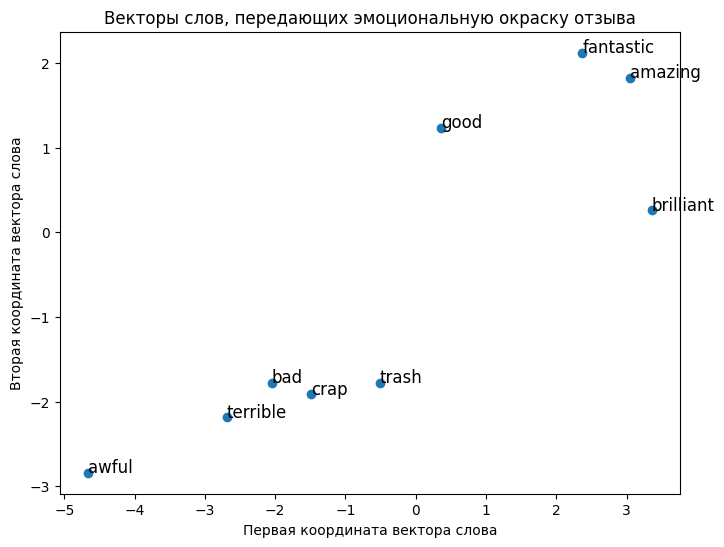

In [81]:
plt.figure(figsize=(8, 6))
plt.scatter(review_vectors[:, 0], review_vectors[:, 1])
for i, txt in enumerate(review):
    plt.annotate(txt, (review_vectors[i, 0], review_vectors[i, 1]), fontsize=12)
plt.xlabel('Первая координата вектора слова')
plt.ylabel('Вторая координата вектора слова')
plt.title('Векторы слов, передающих эмоциональную окраску отзыва')
plt.show()